<a href="https://colab.research.google.com/github/MonishDY/AI-Track/blob/main/Module%203%20-%20Machine%20Learning/Assignment%205/Monish_DY_Assignment_5_ML_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

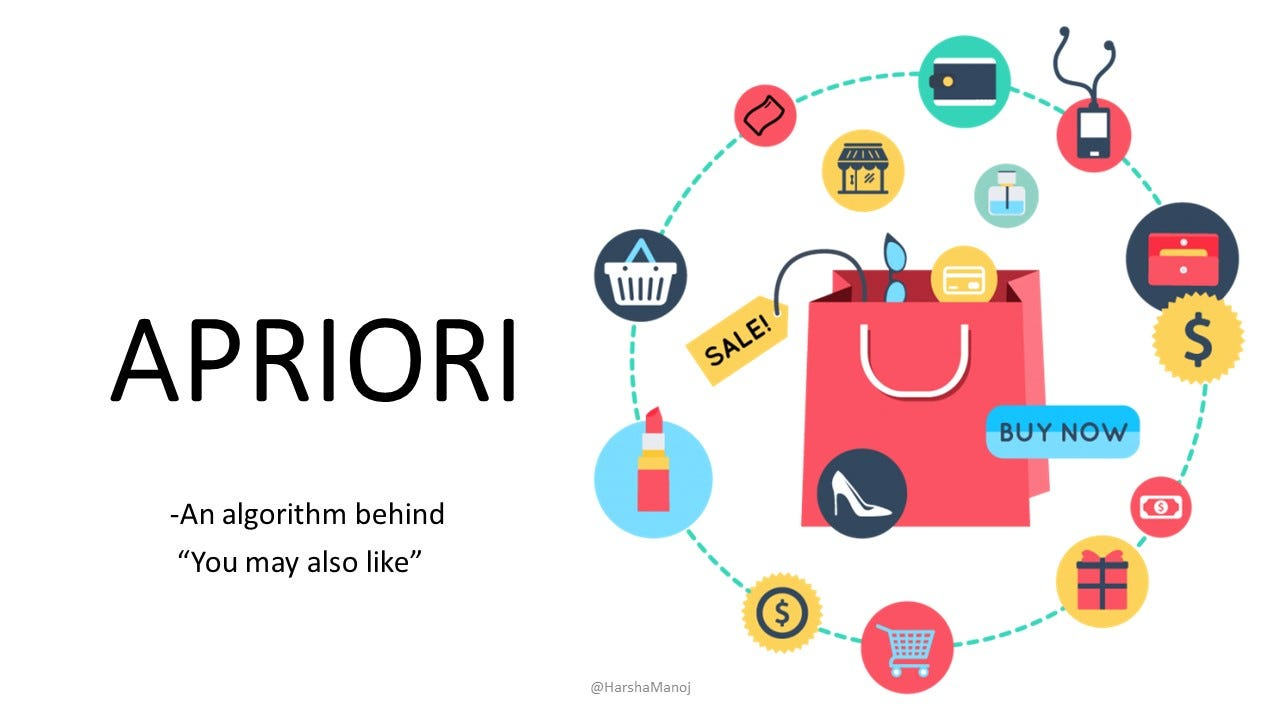

# **Apriori Algorithm and Principal Component Analysis (PCA)**

## **Overall Objectives**

* To implement the **Apriori algorithm** for frequent itemset mining.
* To generate and analyze **association rules** from transaction data.
* To understand **market basket analysis** using support and association rules.
* To implement Apriori **without external data-mining libraries**.
* To apply **PCA for dimensionality reduction** and variance analysis.
* To visualize PCA-transformed data and explained variance.
* To analyze PCA performance on **high-dimensional datasets**.
* To use PCA for **reconstruction-based anomaly detection**.

## **1. Apriori from CSV Dataset**

Read transaction data from a CSV file and perform Apriori analysis.

Tasks:
1. Load CSV file
2. Convert transactions into itemsets
3. Find frequent itemsets
4. Generate association rules.

**Objective:** To perform Apriori analysis on transaction data.

In [1]:
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/MonishDY/AI-Track/refs/heads/main/Module%203%20-%20Machine%20Learning/Assignment%205/Groceries_dataset.csv")

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [2]:
# Convert Transactions into Itemsets
transactions = (
    df.groupby(['Member_number', 'Date'])['itemDescription']
    .apply(set)
    .tolist()
)

print("Number of Transactions:", len(transactions))
transactions[:5]

Number of Transactions: 14963


[{'sausage', 'semi-finished bread', 'whole milk', 'yogurt'},
 {'pastry', 'salty snack', 'whole milk'},
 {'canned beer', 'misc. beverages'},
 {'hygiene articles', 'sausage'},
 {'pickled vegetables', 'soda'}]

In [3]:
# Find Frequent Itemsets
min_support = 0.01
n = len(transactions)

item_counts = {}

for transaction in transactions:
    for item in transaction:
        itemset = frozenset([item])
        item_counts[itemset] = item_counts.get(itemset, 0) + 1

frequent_itemsets = {
    itemset: count / n
    for itemset, count in item_counts.items()
    if count / n >= min_support
}

for size in range(2, 4):

    candidates = {}
    items = list(frequent_itemsets.keys())

    for i in range(len(items)):
        for j in range(i + 1, len(items)):

            itemset = items[i] | items[j]

            if len(itemset) != size:
                continue

            count = sum(
                itemset.issubset(transaction)
                for transaction in transactions
            )

            support = count / n

            if support >= min_support:
                candidates[itemset] = support

    if not candidates:
        break

    frequent_itemsets.update(candidates)

frequent_df = pd.DataFrame([
    {
        'Itemset': ', '.join(sorted(itemset)),
        'Support': support
    }
    for itemset, support in frequent_itemsets.items()
])

frequent_df = frequent_df.sort_values(
    'Support',
    ascending=False
)

frequent_df.head(20)

,Itemset,Support
0,whole milk,0.157923
16,other vegetables,0.122101
11,rolls/buns,0.110005
8,soda,0.097106
2,yogurt,0.085879
22,root vegetables,0.069572
18,tropical fruit,0.067767
29,bottled water,0.060683
1,sausage,0.060349
44,citrus fruit,0.053131


In [4]:
# Generate association rules
min_confidence = 0.05

rules = []

for itemset, support in frequent_itemsets.items():

    if len(itemset) < 2:
        continue

    items = list(itemset)

    for r in range(1, len(items)):

        for antecedent_items in combinations(items, r):

            antecedent = frozenset(antecedent_items)
            consequent = itemset - antecedent

            antecedent_support = frequent_itemsets.get(
                antecedent, 0
            )

            if antecedent_support == 0:
                continue

            confidence = support / antecedent_support

            if confidence >= min_confidence:
                rules.append({
                    'Antecedent': ', '.join(sorted(antecedent)),
                    'Consequent': ', '.join(sorted(consequent)),
                    'Support': support,
                    'Confidence': confidence
                })

if rules:
    rules_df = pd.DataFrame(rules)
    rules_df = rules_df.sort_values(
        'Confidence',
        ascending=False
    )
else:
    rules_df = pd.DataFrame(
        columns=[
            'Antecedent',
            'Consequent',
            'Support',
            'Confidence'
        ]
    )

print("Number of rules:", len(rules_df))

rules_df.head(20)

Number of rules: 10


,Antecedent,Consequent,Support,Confidence
1,yogurt,whole milk,0.011161,0.129961
5,rolls/buns,whole milk,0.013968,0.126974
7,other vegetables,whole milk,0.014837,0.121511
3,soda,whole milk,0.011629,0.119752
8,rolls/buns,other vegetables,0.010559,0.095990
6,whole milk,other vegetables,0.014837,0.093948
4,whole milk,rolls/buns,0.013968,0.088447
9,other vegetables,rolls/buns,0.010559,0.086481
2,whole milk,soda,0.011629,0.073635
0,whole milk,yogurt,0.011161,0.070673


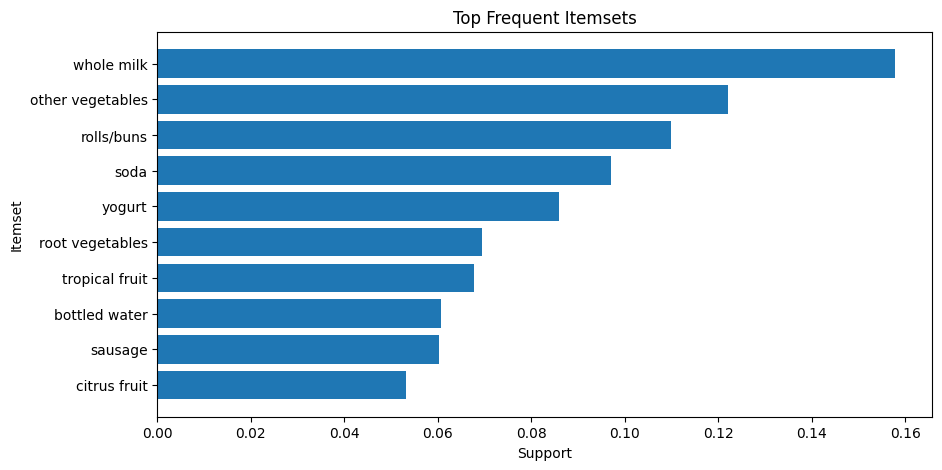

In [5]:
# Plot graph
plot_df = frequent_df.head(10)
plt.figure(figsize=(10, 5))

plt.barh(
    plot_df['Itemset'],
    plot_df['Support']
)

plt.xlabel('Support')
plt.ylabel('Itemset')
plt.title('Top Frequent Itemsets')
plt.gca().invert_yaxis()

plt.show()

## **2. Market Basket Analysis**

Implement Apriori to identify products that are frequently purchased together.

- Find frequent itemsets
- Display support values
- Generate association rules

Use appropriate Dataset

**Objective:** To identify products that are frequently purchased together using Apriori.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [7]:
df = pd.read_csv("https://raw.githubusercontent.com/MonishDY/AI-Track/refs/heads/main/Module%203%20-%20Machine%20Learning/Assignment%205/Groceries_dataset.csv")
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [8]:
transactions = (
    df.groupby(['Member_number', 'Date'])['itemDescription']
    .apply(list)
    .tolist()
)

print("Number of Transactions:", len(transactions))
transactions[:5]

Number of Transactions: 14963


[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables']]

In [9]:
# Convert to Transaction Matrix
te = TransactionEncoder()
transaction_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
# Find frequent itemsets
frequent_itemsets = apriori(
    basket,
    min_support=0.005,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    'support',
    ascending=False
)

frequent_itemsets.head(20)

,support,itemsets
87,0.157923,(whole milk)
53,0.122101,(other vegetables)
66,0.110005,(rolls/buns)
75,0.097106,(soda)
88,0.085879,(yogurt)
67,0.069572,(root vegetables)
81,0.067767,(tropical fruit)
6,0.060683,(bottled water)
70,0.060349,(sausage)
19,0.053131,(citrus fruit)


In [11]:
# Display Support Values
support_df = frequent_itemsets.copy()
support_df['Itemset'] = support_df['itemsets'].apply(
    lambda x: ', '.join(sorted(x))
)

support_df[['Itemset', 'support']].head(20)

,Itemset,support
87,whole milk,0.157923
53,other vegetables,0.122101
66,rolls/buns,0.110005
75,soda,0.097106
88,yogurt,0.085879
67,root vegetables,0.069572
81,tropical fruit,0.067767
6,bottled water,0.060683
70,sausage,0.060349
19,citrus fruit,0.053131


In [12]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.05
)

rules = rules.sort_values(
    ['confidence', 'support'],
    ascending=False
)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

,antecedents,consequents,support,confidence,lift
23,(bottled beer),(whole milk),0.007151,0.157817,0.999330
13,(sausage),(whole milk),0.008955,0.148394,0.939663
43,(newspapers),(whole milk),0.005614,0.144330,0.913926
50,(domestic eggs),(whole milk),0.005280,0.142342,0.901341
52,(frankfurter),(whole milk),0.005280,0.139823,0.885388
55,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
56,(pork),(whole milk),0.005012,0.135135,0.855703
26,(pip fruit),(whole milk),0.006616,0.134877,0.854071
25,(citrus fruit),(whole milk),0.007151,0.134591,0.852259
28,(shopping bags),(whole milk),0.006349,0.133427,0.844887


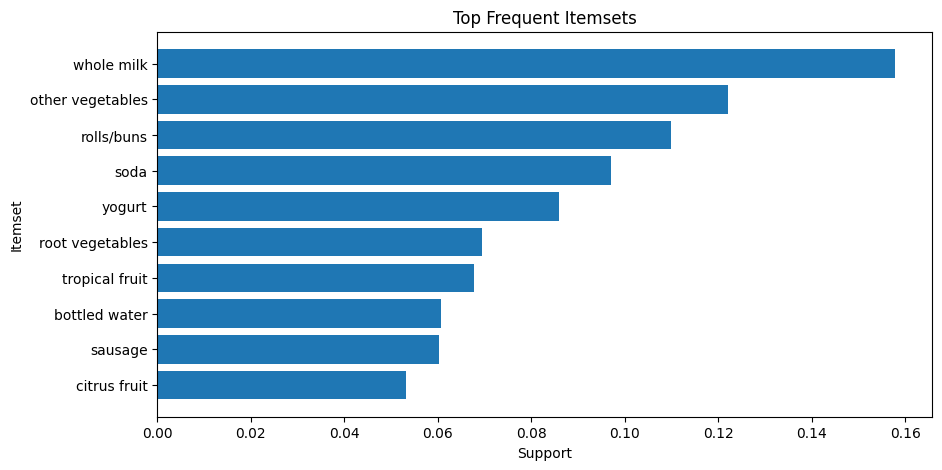

In [13]:
# Plot graph
plot_df = support_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    plot_df['Itemset'],
    plot_df['support']
)
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.title('Top Frequent Itemsets')
plt.gca().invert_yaxis()
plt.show()

## **3. Apriori Algorithm Using Python**

Create a Python implementation without using external data-mining libraries.

**Objective:** To implement the Apriori algorithm using Python.

In [14]:
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Bread', 'Butter', 'Eggs'],
    ['Bread', 'Eggs'],
    ['Milk', 'Butter'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Butter', 'Eggs']
]

transactions = [set(t) for t in transactions]

print("Number of Transactions:", len(transactions))
transactions

Number of Transactions: 8


[{'Bread', 'Butter', 'Milk'},
 {'Bread', 'Butter'},
 {'Bread', 'Milk'},
 {'Bread', 'Butter', 'Eggs', 'Milk'},
 {'Bread', 'Eggs'},
 {'Butter', 'Milk'},
 {'Bread', 'Butter', 'Milk'},
 {'Bread', 'Butter', 'Eggs'}]

In [15]:
min_support = 0.25
n = len(transactions)

item_counts = {}

for transaction in transactions:
    for item in transaction:
        itemset = frozenset([item])
        item_counts[itemset] = item_counts.get(itemset, 0) + 1

frequent_itemsets = {
    itemset: count / n
    for itemset, count in item_counts.items()
    if count / n >= min_support
}

for size in range(2, 4):
    candidates = set()

    current_items = list(frequent_itemsets.keys())

    for i in range(len(current_items)):
        for j in range(i + 1, len(current_items)):
            candidate = current_items[i] | current_items[j]

            if len(candidate) == size:
                candidates.add(candidate)

    new_itemsets = {}

    for itemset in candidates:
        count = sum(
            itemset.issubset(transaction)
            for transaction in transactions
        )

        support = count / n

        if support >= min_support:
            new_itemsets[itemset] = support

    if not new_itemsets:
        break

    frequent_itemsets.update(new_itemsets)

frequent_df = pd.DataFrame([
    {
        'Itemset': ', '.join(sorted(itemset)),
        'Support': support
    }
    for itemset, support in frequent_itemsets.items()
])

frequent_df.sort_values('Support', ascending=False)

,Itemset,Support
0,Bread,0.875
2,Butter,0.750
1,Milk,0.625
5,"Bread, Butter",0.625
4,"Bread, Milk",0.500
6,"Butter, Milk",0.500
3,Eggs,0.375
8,"Bread, Eggs",0.375
10,"Bread, Butter, Milk",0.375
7,"Butter, Eggs",0.250


In [16]:
min_confidence = 0.5
rules = []

for itemset, support in frequent_itemsets.items():

    if len(itemset) < 2:
        continue

    items = list(itemset)

    for r in range(1, len(items)):

        for antecedent_items in combinations(items, r):

            antecedent = frozenset(antecedent_items)
            consequent = itemset - antecedent

            antecedent_support = frequent_itemsets.get(
                antecedent, 0
            )

            if antecedent_support == 0:
                continue

            confidence = support / antecedent_support

            if confidence >= min_confidence:
                rules.append({
                    'Antecedent': ', '.join(sorted(antecedent)),
                    'Consequent': ', '.join(sorted(consequent)),
                    'Support': support,
                    'Confidence': confidence
                })

rules_df = pd.DataFrame(rules)

rules_df.sort_values(
    'Confidence',
    ascending=False
)

,Antecedent,Consequent,Support,Confidence
7,Eggs,Bread,0.375,1.000000
10,"Butter, Eggs",Bread,0.250,1.000000
3,Butter,Bread,0.625,0.833333
4,Milk,Butter,0.500,0.800000
1,Milk,Bread,0.500,0.800000
13,"Bread, Milk",Butter,0.375,0.750000
15,"Butter, Milk",Bread,0.375,0.750000
2,Bread,Butter,0.625,0.714286
9,"Bread, Eggs",Butter,0.250,0.666667
6,Eggs,Butter,0.250,0.666667


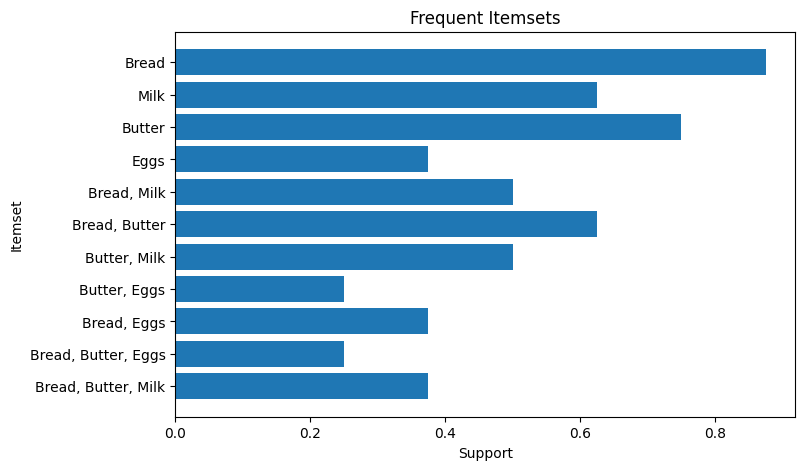

In [17]:
plt.figure(figsize=(8, 5))

plt.barh(
    frequent_df['Itemset'],
    frequent_df['Support']
)

plt.xlabel('Support')
plt.ylabel('Itemset')
plt.title('Frequent Itemsets')

plt.gca().invert_yaxis()
plt.show()

## **4. Apply PCA to the Iris Dataset**

Apply PCA to the Iris Dataset.

**Objective:** To apply PCA to the Iris dataset.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [19]:
# Import dataset
iris = load_iris()

X = iris.data
y = iris.target

In [20]:
# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [21]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Target"] = y
pca_df.head()

,PC1,PC2,Target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


In [22]:
# Explained Variance Ratio
variance_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance": pca.explained_variance_ratio_
})

variance_df

,Principal Component,Explained Variance
0,PC1,0.729624
1,PC2,0.228508


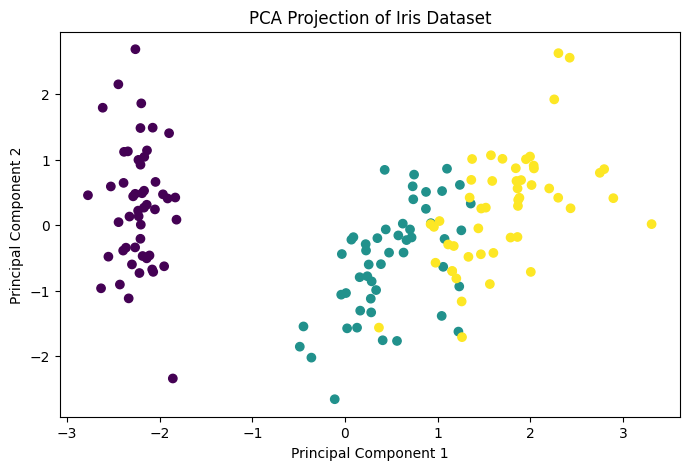

In [23]:
# PCA Scatter Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")
plt.show()

## **5. Principal components needed to retain 95% variance.**

Determine the minimum number of principal components needed to retain 95% variance.

**Objective:** To determine the minimum number of principal components needed to retain 95% variance.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data

In [25]:
# Standardize Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# Apply PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [27]:
# Calculate Variances Ratios
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

variance_df = pd.DataFrame({
    "Principal Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,1,0.729624,0.729624
1,2,0.228508,0.958132
2,3,0.036689,0.994821
3,4,0.005179,1.000000


In [28]:
# Determine minimum components
n_components = (cumulative_variance >= 0.95).argmax() + 1

print("Minimum number of components:", n_components)
print("Retained variance:", cumulative_variance[n_components - 1])

Minimum number of components: 2
Retained variance: 0.9581320720000166


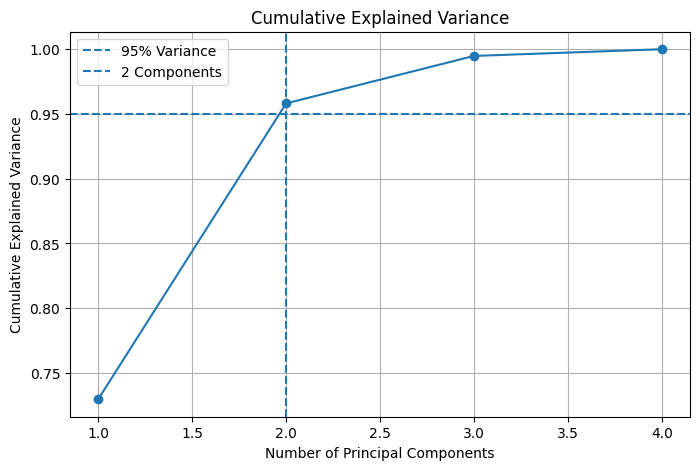

In [29]:
# Plot graph
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(0.95, linestyle="--", label="95% Variance")
plt.axvline(n_components, linestyle="--", label=f"{n_components} Components")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

In [30]:
# PCA with Required Components
pca_95 = PCA(n_components=n_components)
X_pca = pca_95.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


## **6. Compute the explained variance ratio of each principal component.**

Given a set of eigenvalues, write a program to compute the explained variance ratio of each principal component.

Input  eigenvalues = [4.5, 2.1, 1.0, 0.4]

**Objective:** To compute the explained variance ratio of each principal component.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
# Eigen values
eigenvalues = np.array([4.5, 2.1, 1.0, 0.4])

# Calculate Explained Variance Ratio
explained_variance_ratio = eigenvalues / eigenvalues.sum()
explained_variance_ratio

array([0.5625, 0.2625, 0.125 , 0.05  ])

In [33]:
# Display Results
variance_df = pd.DataFrame({
    "Principal Component": range(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_variance_ratio
})

variance_df

,Principal Component,Eigenvalue,Explained Variance Ratio
0,1,4.5,0.5625
1,2,2.1,0.2625
2,3,1.0,0.1250
3,4,0.4,0.0500


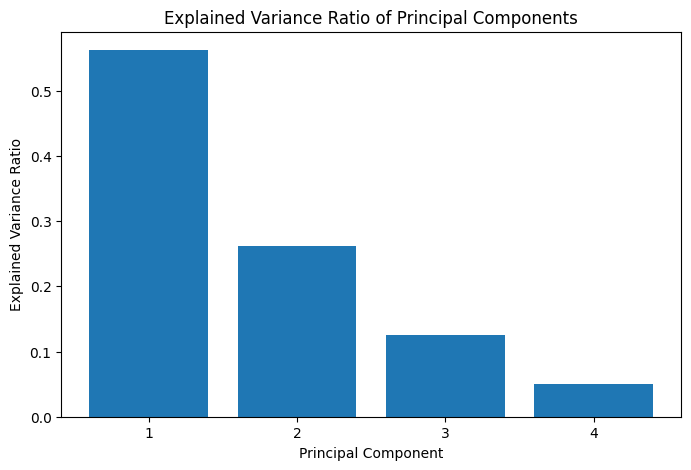

In [34]:
# Plot Explained Variance Ratio
plt.figure(figsize=(8, 5))

plt.bar(
    variance_df["Principal Component"],
    variance_df["Explained Variance Ratio"]
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of Principal Components")
plt.xticks(range(1, len(eigenvalues) + 1))
plt.show()

## **7. Dimensionality Reduction**

Reduce a dataset having 8 features to:

- 4 dimensions
- 2 dimensions

Compare the retained variance.

**Objective:** To reduce the dataset dimensions and compare the retained variance.

In [35]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
X, y = make_regression(
    n_samples=500,
    n_features=8,
    random_state=42
)

X = StandardScaler().fit_transform(X)

In [37]:
# Apply PCA with 4 and 2 components
pca_4 = PCA(n_components=4)
X_4 = pca_4.fit_transform(X)

pca_2 = PCA(n_components=2)
X_2 = pca_2.fit_transform(X)

In [38]:
# Calculate Explained Variance Ratio
variance = pd.DataFrame({
    'Dimensions': ['4 Dimensions', '2 Dimensions'],
    'Retained Variance': [
        pca_4.explained_variance_ratio_.sum(),
        pca_2.explained_variance_ratio_.sum()
    ]
})

variance

,Dimensions,Retained Variance
0,4 Dimensions,0.542328
1,2 Dimensions,0.279248


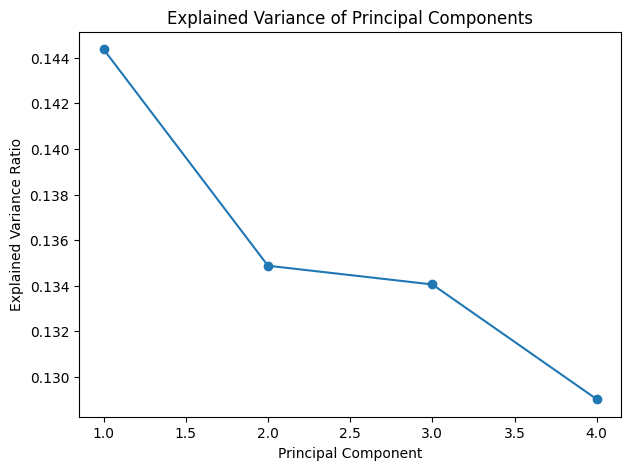

In [39]:
# Plot graph
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 5),
    pca_4.explained_variance_ratio_,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance of Principal Components')

plt.show()

## **8. PCA Visualization**

Apply PCA on a dataset with more than 3 features and project it into 2D.

Generate:
- Scatter plot
- Explained variance plot

**Objective:** To project a dataset into 2D using PCA and visualize the results.

In [40]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

X = StandardScaler().fit_transform(X)

In [42]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Target'] = y
pca_df.head()

,PC1,PC2,Target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


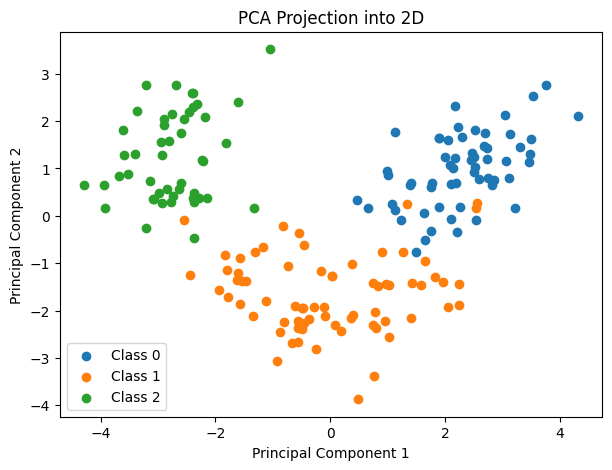

In [43]:
# Plot graph
plt.figure(figsize=(7, 5))

for target in sorted(pca_df['Target'].unique()):
    data = pca_df[pca_df['Target'] == target]
    plt.scatter(
        data['PC1'],
        data['PC2'],
        label=f'Class {target}'
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection into 2D')
plt.legend()
plt.show()

## **9. PCA for High-Dimensional Data**

Given a dataset containing:
10000 samples  1000 features

Perform:
- PCA transformation
- Variance analysis
- Runtime measurement
- Memory usage analysis

**Objective:** To perform PCA on high-dimensional data and analyze its performance.

In [44]:
import numpy as np
import pandas as pd
import time
import tracemalloc
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [45]:
# Create dataset
X, y = make_regression(
    n_samples=10000,
    n_features=1000,
    random_state=42
)

X = StandardScaler().fit_transform(X)

In [46]:
# Calculate necessary parameters
tracemalloc.start()
start_time = time.time()

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

runtime = time.time() - start_time

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

memory_usage = peak / (1024 ** 2)

In [47]:
# Display Results
print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)
print("Retained Variance:", pca.explained_variance_ratio_.sum())
print("Number of Components:", pca.n_components_)
print("Runtime:", round(runtime, 4), "seconds")
print("Peak Memory Usage:", round(memory_usage, 2), "MB")

Original Shape: (10000, 1000)
Reduced Shape: (10000, 908)
Retained Variance: 0.9503870078661443
Number of Components: 908
Runtime: 3.1913 seconds
Peak Memory Usage: 83.94 MB


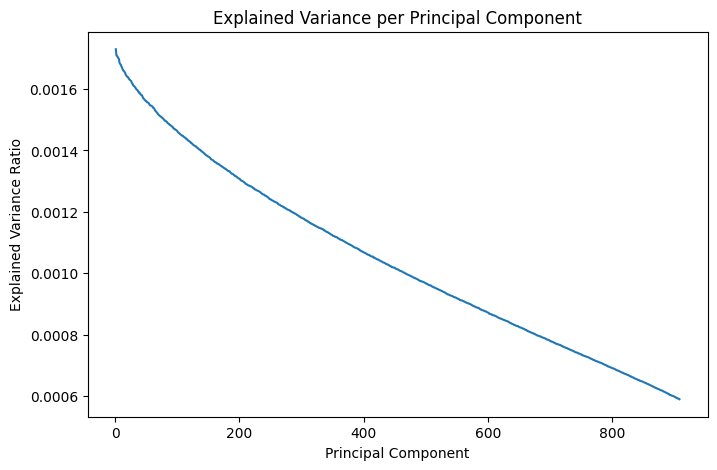

In [48]:
# Plot graph
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Principal Component')

plt.show()

## **10. PCA-Based Anomaly Detection**

Develop a PCA model for anomaly detection.

Requirements
- Train PCA on normal data
- Reconstruct observations
- Compute reconstruction error
- Detect anomalies

**Objective:** To develop a PCA model for anomaly detection.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [50]:
# Create dataset
np.random.seed(42)

normal_data = np.random.normal(0, 1, (500, 5))
anomaly_data = np.random.normal(5, 1, (20, 5))

data = np.vstack([normal_data, anomaly_data])

In [51]:
# Perform standardization
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)
data_scaled = scaler.transform(data)

In [52]:
# Apply PCA
pca = PCA(n_components=2)
pca.fit(normal_scaled)

PCA(n_components=2)

In [53]:
# Reconstruct Observations and Compute Error
data_pca = pca.transform(data_scaled)
data_reconstructed = pca.inverse_transform(data_pca)

reconstruction_error = np.mean(
    (data_scaled - data_reconstructed) ** 2,
    axis=1
)

error_df = pd.DataFrame({
    'Observation': range(len(data)),
    'Reconstruction_Error': reconstruction_error
})

error_df.head()

,Observation,Reconstruction_Error
0,0,0.228662
1,1,0.166694
2,2,1.552698
3,3,0.808846
4,4,0.784454


In [54]:
# Detect Anomalies
threshold = np.percentile(
    reconstruction_error[:len(normal_data)],
    95
)

error_df['Anomaly'] = (
    error_df['Reconstruction_Error'] > threshold
)

print("Threshold:", threshold)
print("Number of Anomalies:", error_df['Anomaly'].sum())

error_df

Threshold: 1.5286081986218776
Number of Anomalies: 45


,Observation,Reconstruction_Error,Anomaly
0,0,0.228662,False
1,1,0.166694,False
2,2,1.552698,True
3,3,0.808846,False
4,4,0.784454,False
...,...,...,...
515,515,17.206517,True
516,516,17.415442,True
517,517,8.749649,True
518,518,12.929254,True


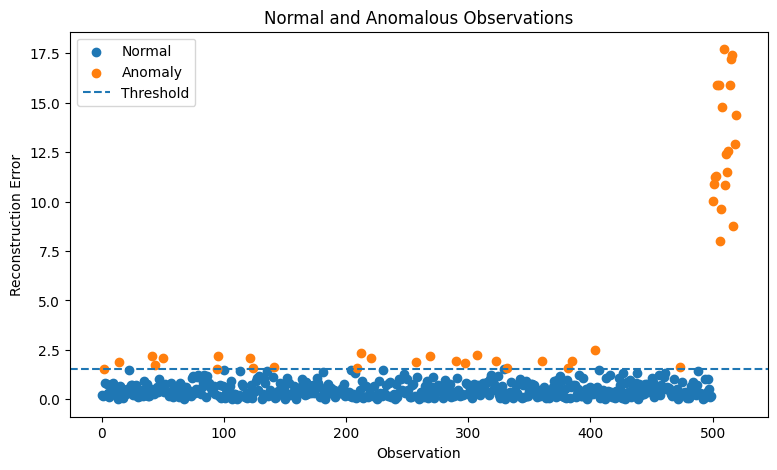

In [55]:
# Plot graph
plt.figure(figsize=(9, 5))

normal = error_df[~error_df['Anomaly']]
anomalies = error_df[error_df['Anomaly']]

plt.scatter(
    normal['Observation'],
    normal['Reconstruction_Error'],
    label='Normal'
)

plt.scatter(
    anomalies['Observation'],
    anomalies['Reconstruction_Error'],
    label='Anomaly'
)

plt.axhline(
    threshold,
    linestyle='--',
    label='Threshold'
)

plt.xlabel('Observation')
plt.ylabel('Reconstruction Error')
plt.title('Normal and Anomalous Observations')
plt.legend()
plt.show()